In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "Girona"
away= "Alavés"

In [3]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
24,Girona,Real Madrid,2025-02-23,L,A,0,2,-2,0,0,...,0.4,0.7,-0.4,-0.4,-0.4,0.07,0,1.7,0.35,-0.3
25,Girona,Celta Vigo,2025-03-01,D,H,2,2,0,2,0,...,0.4,1.0,1.3,1.3,1.6,0.07,1,2.2,0.22,0.2
26,Girona,Espanyol,2025-03-10,D,A,1,1,0,0,1,...,0.5,1.2,-0.6,-0.8,-0.5,0.05,2,0.4,0.09,-0.6
27,Girona,Valencia,2025-03-15,D,H,1,1,0,1,0,...,0.8,1.3,0.1,0.1,0.2,0.07,0,1.4,0.68,0.4
28,Girona,Barcelona,2025-03-30,L,A,1,4,-3,1,0,...,0.5,0.5,0.5,0.5,0.5,0.13,0,3.6,0.40,0.6


In [4]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
24,Real Madrid,Girona,2025-02-23,W,H,2,0,2,2,0,...,1.9,2.0,-0.2,-0.2,-0.9,0.10,0,0.2,0.09,0.2
25,Celta Vigo,Girona,2025-03-01,D,A,2,2,0,1,1,...,1.0,1.0,0.2,-0.1,0.0,0.12,0,1.9,0.32,-0.1
26,Espanyol,Girona,2025-03-10,D,H,1,1,0,1,0,...,0.2,0.2,0.8,0.8,0.8,0.03,0,1.0,0.06,0.0
27,Valencia,Girona,2025-03-15,D,A,1,1,0,1,0,...,0.7,1.0,0.0,0.0,0.3,0.08,1,1.1,0.28,0.1
28,Barcelona,Girona,2025-03-30,W,H,4,1,3,3,0,...,2.0,1.9,0.7,0.7,1.0,0.11,0,0.9,0.45,-0.1


In [5]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
24,Alavés,Espanyol,2025-02-22,L,H,0,1,-1,0,0,...,1.3,1.1,-1.8,-1.8,-1.3,0.12,2,0.4,0.22,-0.6
25,Alavés,Mallorca,2025-03-02,D,A,1,1,0,1,0,...,1.6,0.7,-0.6,-0.6,-0.6,0.09,0,0.9,0.22,-0.1
26,Alavés,Villarreal,2025-03-08,W,H,1,0,1,1,0,...,0.2,0.3,0.0,0.0,-0.2,0.24,0,0.8,0.38,0.8
27,Alavés,Las Palmas,2025-03-14,D,A,2,2,0,2,0,...,1.6,0.7,0.3,0.3,0.4,0.19,0,1.5,0.13,-0.5
28,Alavés,Rayo Vallecano,2025-03-29,L,H,0,2,-2,0,0,...,0.5,0.8,-1.5,-0.7,-0.5,0.06,0,1.2,0.24,-0.8


In [6]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
24,Espanyol,Alavés,2025-02-22,W,A,1,0,1,1,0,...,0.3,0.5,0.6,0.6,0.7,0.05,0,1.6,0.39,1.6
25,Mallorca,Alavés,2025-03-02,D,H,1,1,0,1,0,...,1.1,0.5,-0.1,-0.1,-0.1,0.08,0,2.0,0.29,1.0
26,Villarreal,Alavés,2025-03-08,L,A,0,1,-1,0,0,...,2.8,2.8,-2.8,-2.8,-2.8,0.12,1,1.1,0.43,0.1
27,Las Palmas,Alavés,2025-03-14,D,H,2,2,0,1,1,...,0.4,0.7,0.2,0.0,-0.4,0.08,1,1.8,0.61,-0.2
28,Rayo Vallecano,Alavés,2025-03-29,W,A,2,0,2,2,0,...,0.4,0.4,1.4,1.4,0.6,0.05,1,1.3,0.17,1.3


In [7]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'GF', 'GA', 'GD', 'G-PK', 'PK', 'PKatt', 'PKm', 'Poss', 'Att (GK)', 'Thr', 'Pa Launch%', 'Pa AvgLen', 'Won', 'Lost', 'Won%', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 'PrgC', 'Last3rd Car', 'OppCr', 'Stp', 'Stp%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'GK Att', 'Launch%', 'AvgLen', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'PKcon', 'OG', 'Recov', '#OPA', 'AvgDist', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'PKdef', 'PKA', 'PKms', 'Missed PK%', 'PKAg', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassL

# Desc

# Features

## Offense

In [8]:
offense= ['G-PK', 'PK', 'PKm', 'Poss', 'PKatt', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 
          'PrgC', 'Last3rd Car', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'Sh', 'G/Sh', 
          'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 
          'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 
          'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 
          'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassLive Sc', 'PassDead Sc', 'TO Sc', 'Sh-Sh', 
          'Fld Sc', 'Def-Sc', 'Touches', 'Def Pen', 'Tch Def 3rd', 'Tch Mid 3rd', 'Tch Att 3rd', 'Att Pen', 'Live Tch', 'xG', 
          'npxG', 'xGD', 'npxGD', 'xAG', 'xA', 'G-xG', 'np:G-xG', 'A-xAG', 'npxG/Sh', 'FKAtt', 'GF']

In [9]:
df_home_off= df_home[offense]
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
24,0,0,0,37,0,11,5,45.5,5,45.5,...,-1.7,-1.7,0.4,0.7,-0.4,-0.4,-0.4,0.07,0,0
25,2,0,0,51,0,14,7,50.0,4,28.6,...,-1.2,-0.4,0.4,1.0,1.3,1.3,1.6,0.07,1,2
26,0,1,0,67,1,20,9,45.0,8,40.0,...,1.3,0.5,0.5,1.2,-0.6,-0.8,-0.5,0.05,2,1
27,1,0,0,57,0,17,9,52.9,8,47.1,...,-0.1,-0.1,0.8,1.3,0.1,0.1,0.2,0.07,0,1
28,1,0,0,31,0,11,7,63.6,3,27.3,...,-1.8,-1.8,0.5,0.5,0.5,0.5,0.5,0.13,0,1


In [10]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
24,2,0,0,63,0,18,10,55.6,8,44.4,...,1.7,1.7,1.9,2.0,-0.2,-0.2,-0.9,0.10,0,2
25,1,1,0,49,1,17,8,47.1,7,41.2,...,1.2,0.4,1.0,1.0,0.2,-0.1,0.0,0.12,0,2
26,1,0,0,33,0,19,8,42.1,10,52.6,...,-1.3,-0.5,0.2,0.2,0.8,0.8,0.8,0.03,0,1
27,1,0,0,43,0,14,9,64.3,2,14.3,...,0.1,0.1,0.7,1.0,0.0,0.0,0.3,0.08,1,1
28,3,0,0,69,0,25,13,52.0,12,48.0,...,1.8,1.8,2.0,1.9,0.7,0.7,1.0,0.11,0,4


In [11]:
df_away_off= df_away[offense]
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
24,0,0,0,62,0,18,8,44.4,9,50.0,...,1.3,1.3,1.3,1.1,-1.8,-1.8,-1.3,0.12,2,0
25,1,0,0,56,0,18,5,27.8,9,50.0,...,0.5,0.5,1.6,0.7,-0.6,-0.6,-0.6,0.09,0,1
26,1,0,0,32,0,20,8,40.0,9,45.0,...,-1.8,-1.8,0.2,0.3,0.0,0.0,-0.2,0.24,0,1
27,2,0,0,39,0,15,9,60.0,4,26.7,...,-0.1,0.7,1.6,0.7,0.3,0.3,0.4,0.19,0,2
28,0,0,1,55,1,18,6,33.3,10,55.6,...,0.9,0.1,0.5,0.8,-1.5,-0.7,-0.5,0.06,0,0


In [12]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
24,1,0,0,38,0,22,10,45.5,9,40.9,...,-1.3,-1.3,0.3,0.5,0.6,0.6,0.7,0.05,0,1
25,1,0,0,44,0,18,6,33.3,8,44.4,...,-0.5,-0.5,1.1,0.5,-0.1,-0.1,-0.1,0.08,0,1
26,0,0,0,68,0,33,12,36.4,18,54.5,...,1.8,1.8,2.8,2.8,-2.8,-2.8,-2.8,0.12,1,0
27,1,1,0,61,1,21,11,52.4,7,33.3,...,0.1,-0.7,0.4,0.7,0.2,0.0,-0.4,0.08,1,2
28,2,0,0,45,0,19,8,42.1,9,47.4,...,-0.9,-0.1,0.4,0.4,1.4,1.4,0.6,0.05,1,2


## Defence

In [13]:
defence= ['OppCr', 'Stp', 'Stp%', 'PKcon', '#OPA', 'AvgDist', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'SoTA', 'Saves', 
          'Save%', 'Tkl', 'TklW', 'Tkl Def 3rd', 'Tkl Mid 3rd', 'Tkl Att 3rd', 'Tkl.2', 'Tkl Att', 'Tkl%', 'Lost Tkl', 
          'Ints', 'BlcSh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',  'PSxG', 'PSxG/SoT', 'PSxG+/-', 'GA']

In [14]:
df_home_def= df_home[defence]
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
24,9,0,0.0,0,0,2.5,0,NaN,0,1,...,4,4,9,24,26,0,1.7,0.35,-0.3,2
25,7,2,28.6,1,1,10.8,0,0.0,0,0,...,2,6,12,29,15,1,2.2,0.22,0.2,2
26,9,0,0.0,0,1,19.3,0,NaN,0,0,...,2,4,6,22,9,0,0.4,0.09,-0.6,1
27,14,0,0.0,0,2,19.3,0,NaN,0,0,...,3,6,12,20,19,2,1.4,0.68,0.4,1
28,17,2,11.8,0,1,8.0,0,NaN,0,0,...,4,7,11,28,30,3,3.6,0.40,0.6,4


In [15]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
24,11,0,0.0,0,1,16.0,0,NaN,0,0,...,2,1,5,14,18,0,0.2,0.09,0.2,0
25,13,0,0.0,0,3,21.3,0,NaN,0,1,...,1,4,5,20,28,0,1.9,0.32,-0.1,2
26,25,3,12.0,1,0,8.5,0,0.0,0,0,...,8,3,5,23,42,0,1.0,0.06,0.0,1
27,24,2,8.3,0,1,17.7,0,NaN,0,0,...,4,6,6,23,43,0,1.1,0.28,0.1,1
28,9,0,0.0,0,3,21.7,0,NaN,0,0,...,1,8,8,18,10,0,0.9,0.45,-0.1,1


In [16]:
df_away_def= df_away[defence]
df_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,9,0,0.0,0,1,20.5,0,NaN,0,0,...,0,8,8,25,12,0,1.7,0.43,-0.3,2
1,12,0,0.0,0,2,24.0,0,NaN,0,0,...,2,11,14,33,18,0,0.4,0.13,0.4,0
2,14,1,7.1,0,0,4.0,0,NaN,0,0,...,3,7,6,19,27,0,0.5,0.50,-0.5,1
3,14,1,7.1,0,0,8.8,0,NaN,0,0,...,1,6,8,24,23,0,1.1,0.18,1.1,0
4,8,1,12.5,1,0,11.3,0,0.0,0,0,...,1,2,11,27,7,0,2.4,0.48,-0.6,3


In [17]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,13,0,0.0,0,0,14.0,0,NaN,0,0,...,3,2,11,29,25,1,1.0,0.49,0.0,1
1,17,1,5.9,0,2,19.0,0,NaN,0,0,...,3,9,10,25,20,0,0.1,0.09,0.1,0
2,18,1,5.6,1,3,23.3,0,0.0,0,0,...,1,5,4,16,23,1,2.2,0.25,0.2,2
3,13,2,15.4,1,0,3.0,0,NaN,0,0,...,4,7,4,14,18,0,1.8,0.36,-0.2,2
4,32,3,9.4,0,1,7.5,0,NaN,0,1,...,6,11,4,21,48,2,2.7,0.51,0.7,2


## Combined

In [18]:
combined= ['Won', 'Lost', 'Won%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Recov']

In [19]:
df_home_cmb= df_home[combined]
df_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
24,3,5,37.5,2,0,0,7,1,26
25,9,11,45.0,0,0,0,8,16,40
26,14,9,60.9,3,0,0,13,11,37
27,9,11,45.0,2,0,0,12,5,45
28,5,9,35.7,1,0,0,11,8,36


In [20]:
df_vs_home_cmb= df_vs_home[combined]
df_vs_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
24,5,3,62.5,0,0,0,1,7,34
25,11,9,55.0,0,0,0,17,8,34
26,9,14,39.1,3,0,0,11,12,27
27,11,9,55.0,1,0,0,5,12,40
28,9,5,64.3,0,0,0,8,11,45


In [21]:
df_away_cmb= df_away[combined]
df_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
24,29,20,59.2,2,0,0,13,17,48
25,21,30,41.2,2,0,0,14,19,42
26,10,12,45.5,4,2,1,11,12,38
27,20,20,50.0,4,0,0,22,10,32
28,23,24,48.9,3,0,0,14,11,59


In [22]:
df_vs_away_cmb= df_vs_away[combined]
df_vs_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
24,20,29,40.8,2,0,0,17,13,41
25,30,21,58.8,0,0,0,20,13,34
26,12,10,54.5,1,0,0,13,9,38
27,20,20,50.0,5,0,0,10,21,30
28,24,23,51.1,5,0,0,12,14,53


## By Team

In [23]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    #for col in target_cols:
     #   for lag in range(1, window+1):
      #      df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [24]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
24,0,0,0,37,0,11,5,45.5,5,45.5,...,0.200,0.408248,0.450,0.369685,0.0675,0.037749,0.50,0.577350,1.00,0.816497
25,2,0,0,51,0,14,7,50.0,4,28.6,...,0.100,0.509902,0.225,0.556028,0.0650,0.036968,0.25,0.500000,0.75,0.957427
26,0,1,0,67,1,20,9,45.0,8,40.0,...,0.225,0.745542,0.400,0.864099,0.0550,0.023805,0.50,0.577350,0.75,0.957427
27,1,0,0,57,0,17,9,52.9,8,47.1,...,0.050,0.911043,0.275,0.970824,0.0625,0.009574,1.00,0.816497,1.00,0.816497
28,1,0,0,31,0,11,7,63.6,3,27.3,...,0.050,0.911043,0.225,0.967385,0.0650,0.010000,0.75,0.957427,1.00,0.816497


In [25]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
24,2,0,0,63,0,18,10,55.6,8,44.4,...,-0.075,0.997914,-0.150,0.568624,0.1200,0.040825,0.50,0.57735,2.00,0.816497
25,1,1,0,49,1,17,8,47.1,7,41.2,...,-0.025,0.981071,-0.275,0.684957,0.1100,0.039158,0.50,0.57735,2.00,0.816497
26,1,0,0,33,0,19,8,42.1,10,52.6,...,0.075,0.935860,-0.150,0.675771,0.1025,0.030957,0.50,0.57735,2.25,0.500000
27,1,0,0,43,0,14,9,64.3,2,14.3,...,0.475,0.763217,0.150,0.785281,0.0775,0.040311,0.25,0.50000,1.75,0.500000
28,3,0,0,69,0,25,13,52.0,12,48.0,...,0.125,0.457347,0.050,0.714143,0.0825,0.038622,0.25,0.50000,1.50,0.577350


In [26]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
24,10,1,10.0,0,1,15.5,0,0.0,0,0,...,0.25,0.5,1.450,0.873689,0.2625,0.116726,-0.050,0.479583,1.50,1.000000
25,15,1,6.7,0,0,12.3,0,0.0,0,0,...,0.25,0.5,1.425,0.910586,0.2575,0.118427,-0.075,0.512348,1.50,1.000000
26,16,0,0.0,0,0,8.0,0,0.0,0,0,...,0.00,0.0,1.350,0.946925,0.2050,0.030000,-0.150,0.479583,1.50,1.000000
27,21,0,0.0,1,0,10.3,0,0.0,0,0,...,0.00,0.0,1.175,0.974252,0.2600,0.080000,-0.075,0.618466,1.25,1.258306
28,8,0,0.0,0,1,14.3,0,0.0,0,1,...,0.25,0.5,0.900,0.454606,0.2375,0.104043,-0.100,0.637704,1.00,0.816497


In [27]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
24,22,2,9.1,0,0,10.4,0,0.0,0,0,...,0.25,0.5,1.000,1.191638,0.113333,0.120554,1.387779e-17,0.294392,1.00,1.414214
25,29,1,3.4,0,1,15.8,0,0.0,0,1,...,0.00,0.0,1.175,1.223043,0.243333,0.145029,4.250000e-01,0.834166,0.75,1.500000
26,12,1,8.3,0,1,9.5,0,0.0,0,0,...,0.00,0.0,1.675,0.963933,0.255000,0.120692,6.750000e-01,0.813941,1.00,1.414214
27,7,0,0.0,0,0,14.0,0,0.0,0,0,...,0.00,0.0,1.850,0.675771,0.337500,0.087702,6.000000e-01,0.860233,1.25,1.258306
28,26,4,15.4,1,0,4.2,1,100.0,0,0,...,0.00,0.0,1.625,0.386221,0.430000,0.133666,6.250000e-01,0.826136,1.00,0.816497


In [28]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
24,0,0,0,62,0,18,8,44.4,9,50.0,...,-0.150,1.021437,-0.025,1.024288,0.075,0.036968,0.0,0.0,1.00,1.414214
25,1,0,0,56,0,18,5,27.8,9,50.0,...,-0.550,1.317826,-0.325,1.212092,0.085,0.043589,0.5,1.0,0.75,1.500000
26,1,0,0,32,0,20,8,40.0,9,45.0,...,-0.675,1.284199,-0.450,1.206924,0.100,0.024495,0.5,1.0,1.00,1.414214
27,2,0,0,39,0,15,9,60.0,4,26.7,...,-0.325,1.209339,-0.200,1.098484,0.130,0.076158,0.5,1.0,1.25,1.258306
28,0,0,1,55,1,18,6,33.3,10,55.6,...,-0.525,0.928709,-0.425,0.713559,0.160,0.067823,0.5,1.0,1.00,0.816497


In [29]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
24,1,0,0,38,0,22,10,45.5,9,40.9,...,0.375,0.499166,0.325,0.629153,0.0425,0.033040,0.00,0.00000,1.50,1.000000
25,1,0,0,44,0,18,6,33.3,8,44.4,...,0.300,0.408248,0.275,0.573730,0.0500,0.029439,0.00,0.00000,1.50,1.000000
26,0,0,0,68,0,33,12,36.4,18,54.5,...,0.275,0.434933,0.350,0.465475,0.0475,0.025000,0.00,0.00000,1.50,1.000000
27,1,1,0,61,1,21,11,52.4,7,33.3,...,-0.400,1.639105,-0.350,1.682260,0.0725,0.035940,0.25,0.50000,1.25,1.258306
28,2,0,0,45,0,19,8,42.1,9,47.4,...,-0.575,1.515201,-0.650,1.506652,0.0825,0.028723,0.50,0.57735,1.00,0.816497


In [30]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
24,9,0,0.0,0,0,2.5,0,0.0,0,1,...,3.00,0.816497,2.075,1.309898,0.3700,0.180000,0.075,0.718215,2.00,0.816497
25,7,2,28.6,1,1,10.8,0,0.0,0,0,...,2.25,1.707825,2.050,1.317826,0.3925,0.166808,0.050,0.732575,2.00,0.816497
26,9,0,0.0,0,1,19.3,0,0.0,0,0,...,2.00,1.825742,2.300,1.191638,0.2925,0.084607,0.050,0.732575,2.25,0.500000
27,14,0,0.0,0,2,19.3,0,0.0,0,0,...,1.00,1.414214,1.400,0.761577,0.2200,0.106145,-0.350,0.404145,1.75,0.500000
28,17,2,11.8,0,1,8.0,0,0.0,0,0,...,0.75,0.957427,1.425,0.758837,0.3350,0.253311,-0.075,0.457347,1.50,0.577350


In [31]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
24,11,0,0.0,0,1,16.0,0,0.0,0,0,...,0.25,0.5,1.275,0.939415,0.2725,0.117296,0.275,0.125831,1.00,0.816497
25,13,0,0.0,0,3,21.3,0,0.0,0,1,...,0.00,0.0,1.000,1.080123,0.2275,0.148857,0.250,0.129099,0.75,0.957427
26,25,3,12.0,1,0,8.5,0,0.0,0,0,...,0.00,0.0,0.875,0.873212,0.2125,0.130224,0.125,0.170783,0.75,0.957427
27,24,2,8.3,0,1,17.7,0,0.0,0,0,...,0.00,0.0,1.100,0.707107,0.2000,0.144914,0.100,0.182574,1.00,0.816497
28,9,0,0.0,0,3,21.7,0,0.0,0,0,...,0.00,0.0,1.050,0.695222,0.1875,0.131498,0.050,0.129099,1.00,0.816497


In [32]:
df_home_cmb.rename(columns= {col: f"h_{col}" for col in df_home_cmb.columns}, inplace= True)
df_home_cmb= create_lagged_features(df_home_cmb, df_home_cmb.columns)
df_home_cmb.tail()

,h_Won,h_Lost,h_Won%,h_CrdY,h_CrdR,h_2CrdY,h_Fls,h_Fld,h_Recov,h_Won_rolling_avg_4,...,h_CrdR_rolling_avg_4,h_CrdR_rolling_std_4,h_2CrdY_rolling_avg_4,h_2CrdY_rolling_std_4,h_Fls_rolling_avg_4,h_Fls_rolling_std_4,h_Fld_rolling_avg_4,h_Fld_rolling_std_4,h_Recov_rolling_avg_4,h_Recov_rolling_std_4
24,3,5,37.5,2,0,0,7,1,26,9.50,...,0.25,0.5,0.0,0.0,11.00,1.414214,14.50,6.244998,38.25,0.957427
25,9,11,45.0,0,0,0,8,16,40,7.75,...,0.25,0.5,0.0,0.0,10.50,2.380476,10.25,8.460693,35.25,6.238322
26,14,9,60.9,3,0,0,13,11,37,7.00,...,0.25,0.5,0.0,0.0,9.50,2.380476,11.25,8.958236,36.00,6.683313
27,9,11,45.0,2,0,0,12,5,45,9.00,...,0.25,0.5,0.0,0.0,9.75,2.753785,12.25,8.539126,35.50,6.454972
28,5,9,35.7,1,0,0,11,8,36,8.75,...,0.00,0.0,0.0,0.0,10.00,2.943920,8.25,6.601767,37.00,8.041559


In [33]:
df_vs_home_cmb.rename(columns= {col: f"vh_{col}" for col in df_vs_home_cmb.columns}, inplace= True)
df_vs_home_cmb= create_lagged_features(df_vs_home_cmb, df_vs_home_cmb.columns)
df_vs_home_cmb.tail()

,vh_Won,vh_Lost,vh_Won%,vh_CrdY,vh_CrdR,vh_2CrdY,vh_Fls,vh_Fld,vh_Recov,vh_Won_rolling_avg_4,...,vh_CrdR_rolling_avg_4,vh_CrdR_rolling_std_4,vh_2CrdY_rolling_avg_4,vh_2CrdY_rolling_std_4,vh_Fls_rolling_avg_4,vh_Fls_rolling_std_4,vh_Fld_rolling_avg_4,vh_Fld_rolling_std_4,vh_Recov_rolling_avg_4,vh_Recov_rolling_std_4
24,5,3,62.5,0,0,0,1,7,34,10.0,...,0.0,0.0,0.0,0.0,15.25,7.135592,10.75,1.892969,39.50,7.047458
25,11,9,55.0,0,0,0,17,8,34,9.0,...,0.0,0.0,0.0,0.0,10.75,9.322911,10.50,2.380476,37.00,6.683313
26,9,14,39.1,3,0,0,11,12,27,8.5,...,0.0,0.0,0.0,0.0,12.00,9.865766,9.50,2.380476,37.25,6.500000
27,11,9,55.0,1,0,0,5,12,40,8.5,...,0.0,0.0,0.0,0.0,13.00,9.380832,9.50,2.380476,32.25,3.500000
28,9,5,64.3,0,0,0,8,11,45,9.0,...,0.0,0.0,0.0,0.0,8.50,7.000000,9.75,2.629956,33.75,5.315073


In [34]:
df_away_cmb.rename(columns= {col: f"va_{col}" for col in df_away_cmb.columns}, inplace= True)
df_away_cmb= create_lagged_features(df_away_cmb, df_away_cmb.columns)
df_away_cmb.tail()

,va_Won,va_Lost,va_Won%,va_CrdY,va_CrdR,va_2CrdY,va_Fls,va_Fld,va_Recov,va_Won_rolling_avg_4,...,va_CrdR_rolling_avg_4,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4
24,29,20,59.2,2,0,0,13,17,48,23.00,...,0.0,0.0,0.00,0.0,16.50,2.380476,13.00,3.915780,38.25,11.557826
25,21,30,41.2,2,0,0,14,19,42,23.25,...,0.0,0.0,0.00,0.0,16.00,2.943920,14.25,4.272002,37.25,10.045729
26,10,12,45.5,4,2,1,11,12,38,24.00,...,0.0,0.0,0.00,0.0,14.50,1.290994,17.00,1.632993,39.75,9.535023
27,20,20,50.0,4,0,0,22,10,32,19.25,...,0.5,1.0,0.25,0.5,13.25,1.707825,16.25,2.986079,38.50,9.291573
28,23,24,48.9,3,0,0,14,11,59,20.00,...,0.5,1.0,0.25,0.5,15.00,4.830459,14.50,4.203173,40.00,6.733003


In [35]:
df_vs_away_cmb.rename(columns= {col: f"a_{col}" for col in df_vs_away_cmb.columns}, inplace= True)
df_vs_away_cmb= create_lagged_features(df_vs_away_cmb, df_vs_away_cmb.columns)
df_vs_away_cmb.tail()

,a_Won,a_Lost,a_Won%,a_CrdY,a_CrdR,a_2CrdY,a_Fls,a_Fld,a_Recov,a_Won_rolling_avg_4,...,a_CrdR_rolling_avg_4,a_CrdR_rolling_std_4,a_2CrdY_rolling_avg_4,a_2CrdY_rolling_std_4,a_Fls_rolling_avg_4,a_Fls_rolling_std_4,a_Fld_rolling_avg_4,a_Fld_rolling_std_4,a_Recov_rolling_avg_4,a_Recov_rolling_std_4
24,20,29,40.8,2,0,0,17,13,41,19.50,...,0.25,0.5,0.0,0.0,14.00,4.320494,15.00,2.943920,34.00,11.690452
25,30,21,58.8,0,0,0,20,13,34,19.50,...,0.25,0.5,0.0,0.0,14.75,4.573474,14.50,3.109126,32.25,9.142392
26,12,10,54.5,1,0,0,13,9,38,22.75,...,0.25,0.5,0.0,0.0,17.75,1.707825,13.00,0.816497,33.00,9.128709
27,20,20,50.0,5,0,0,10,21,30,19.75,...,0.25,0.5,0.0,0.0,17.00,2.943920,12.25,2.217356,33.25,9.287088
28,24,23,51.1,5,0,0,12,14,53,20.50,...,0.00,0.0,0.0,0.0,15.00,4.396969,14.00,5.033223,35.75,4.787136


In [36]:
df_home_off.drop(columns=['GF'], inplace= True)
df_away_off.drop(columns=['GF'], inplace= True)
df_vs_home_off.drop(columns=['GF'], inplace= True)
df_vs_away_off.drop(columns=['GF'], inplace= True)

df_home_def.drop(columns=['GA'], inplace= True)
df_away_def.drop(columns=['GA'], inplace= True)
df_vs_home_def.drop(columns=['GA'], inplace= True)
df_vs_away_def.drop(columns=['GA'], inplace= True)

## Final DFs

In [37]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
#df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4,H/A
0,1,0,0,31,0,11,7,63.6,3,27.3,...,0.5,0.9,0.454606,0.2375,0.104043,-0.1,0.637704,1.0,0.816497,H


In [38]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_home[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,1,0,0,61,0,16,8,50.0,7,43.8,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,A,0
1,0,0,0,57,0,19,12,63.2,7,36.8,...,0.0,0.0,23.000000,0.000000,6.000000,0.000000,37.00,0.000000,H,4
2,4,0,0,60,0,15,7,46.7,7,46.7,...,0.0,0.0,20.000000,4.242641,10.500000,6.363961,43.50,9.192388,A,2
3,1,1,0,50,1,23,10,43.5,12,52.2,...,0.0,0.0,17.666667,5.033223,12.333333,5.507571,41.00,7.810250,H,1
4,1,0,0,45,0,17,9,52.9,8,47.1,...,0.0,0.0,16.500000,4.725816,11.500000,4.795832,36.75,10.626225,A,0


In [39]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,17,2,11.8,0,1,8.0,0,0.0,0,0,...,1.0,0.25,0.5,15.0,4.830459,14.5,4.203173,40.0,6.733003,H


In [40]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_home[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,8,1,12.5,0,2,15.8,0,0.0,0,1,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,A,3
1,5,1,20.0,0,0,11.3,0,0.0,1,0,...,0.0,0.0,23.000000,0.000000,6.000000,0.000000,37.00,0.000000,H,0
2,5,1,20.0,0,2,24.7,0,0.0,0,0,...,0.0,0.0,20.000000,4.242641,10.500000,6.363961,43.50,9.192388,A,0
3,8,1,12.5,0,1,16.0,0,0.0,0,0,...,0.0,0.0,17.666667,5.033223,12.333333,5.507571,41.00,7.810250,H,4
4,14,0,0.0,0,2,31.5,0,0.0,0,0,...,0.0,0.0,16.500000,4.725816,11.500000,4.795832,36.75,10.626225,A,2


In [41]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,0,0,1,55,1,18,6,33.3,10,55.6,...,1.0,0.25,0.5,15.0,4.830459,14.5,4.203173,40.0,6.733003,A


In [42]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_away[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,1,0,0,37,0,15,4,26.7,10,66.7,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,H,0
1,0,0,0,38,0,17,6,35.3,10,58.8,...,0.0,0.0,23.000000,0.000000,6.000000,0.000000,37.00,0.000000,A,2
2,1,1,0,47,1,13,6,46.2,5,38.5,...,0.0,0.0,20.000000,4.242641,10.500000,6.363961,43.50,9.192388,H,2
3,2,0,1,30,1,13,7,53.8,5,38.5,...,0.0,0.0,17.666667,5.033223,12.333333,5.507571,41.00,7.810250,A,2
4,2,0,0,61,0,15,5,33.3,7,46.7,...,0.0,0.0,16.500000,4.725816,11.500000,4.795832,36.75,10.626225,H,2


In [43]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,8,0,0.0,0,1,14.3,0,0.0,0,1,...,1.0,0.25,0.5,15.0,4.830459,14.5,4.203173,40.0,6.733003,H


In [44]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1],
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_away[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,9,0,0.0,0,1,20.5,0,0.0,0,0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,H,0
1,12,0,0.0,0,2,24.0,0,0.0,0,0,...,0.0,0.0,23.000000,0.000000,6.000000,0.000000,37.00,0.000000,A,1
2,14,1,7.1,0,0,4.0,0,0.0,0,0,...,0.0,0.0,20.000000,4.242641,10.500000,6.363961,43.50,9.192388,H,0
3,14,1,7.1,0,0,8.8,0,0.0,0,0,...,0.0,0.0,17.666667,5.033223,12.333333,5.507571,41.00,7.810250,A,3
4,8,1,12.5,1,0,11.3,0,0.0,0,0,...,0.0,0.0,16.500000,4.725816,11.500000,4.795832,36.75,10.626225,H,1


In [45]:
df_home_gf = df_home_gf.fillna(0)

In [46]:
df_home_ga = df_home_ga.fillna(0)

In [47]:
df_away_ga = df_away_ga.fillna(0)

In [48]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [49]:
# Define bins for football goals classification
bins = [-1, 0, 1, 2, 3, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4]  # Assigning numeric class labels

# Apply binning
df_home_gf['GFC'] = pd.cut(df_home_gf['GF'], bins=bins, labels=labels)
df_away_gf['GFC'] = pd.cut(df_away_gf['GF'], bins=bins, labels=labels)
df_home_ga['GAC'] = pd.cut(df_home_ga['GA'], bins=bins, labels=labels)
df_away_ga['GAC'] = pd.cut(df_away_ga['GA'], bins=bins, labels=labels)

In [50]:
df_home_gf.drop(columns=['GF'], inplace= True)
df_away_gf.drop(columns=['GF'], inplace= True)

df_home_ga.drop(columns=['GA'], inplace= True)
df_away_ga.drop(columns=['GA'], inplace= True)


# Models

## Classification

### Model Home

In [51]:
target = "GFC"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [52]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [53]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

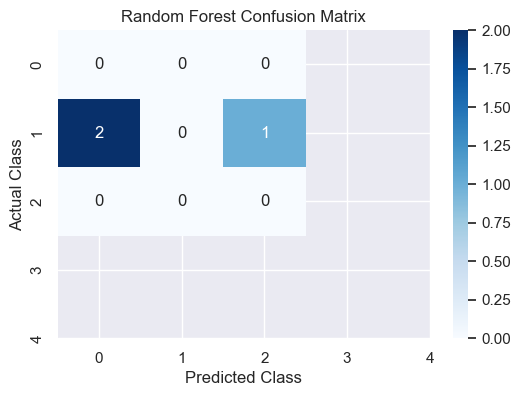

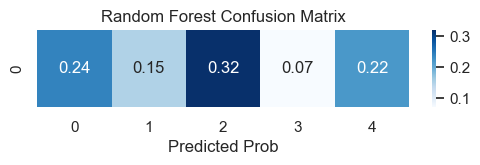

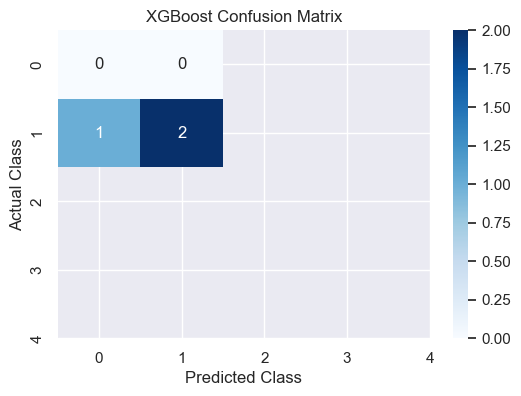

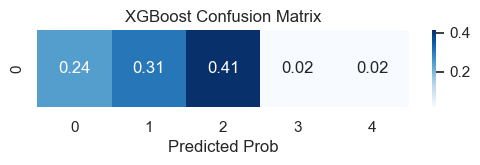

In [54]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [55]:
target = "GAC"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [56]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

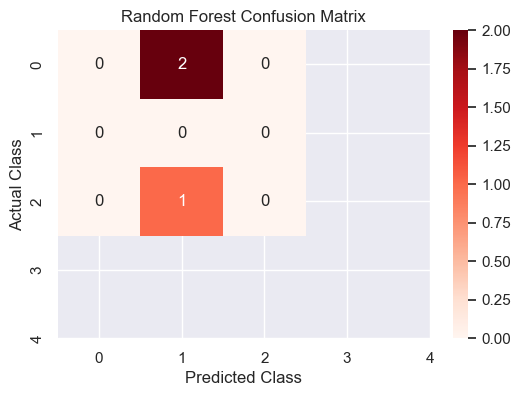

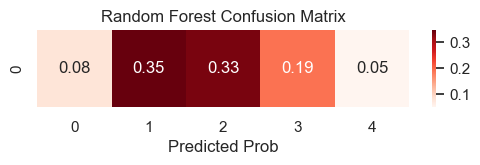

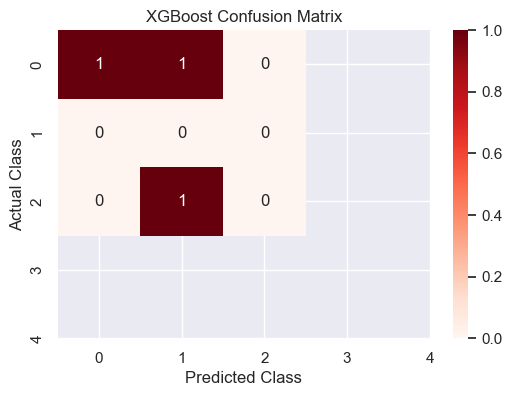

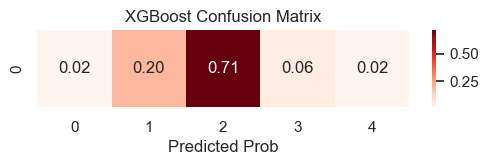

In [58]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [59]:
target = "GFC"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [60]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [61]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

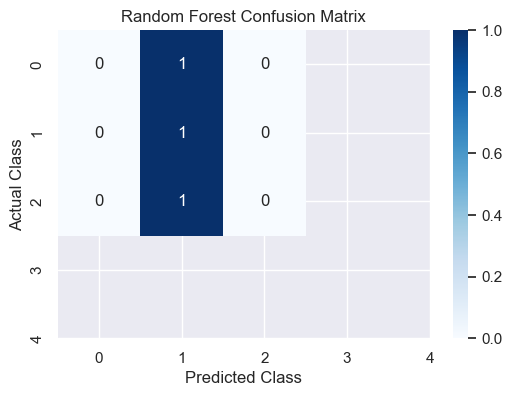

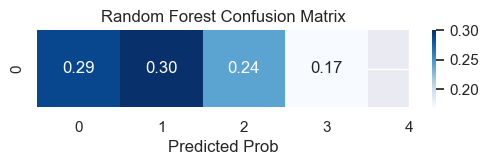

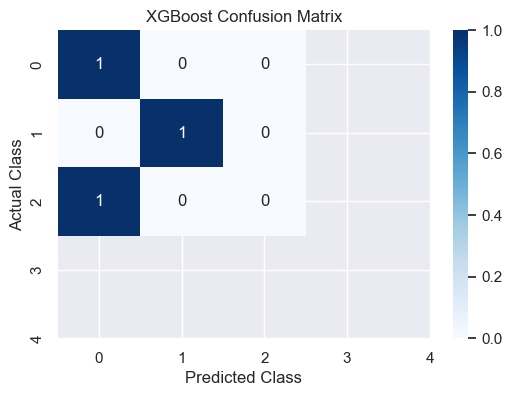

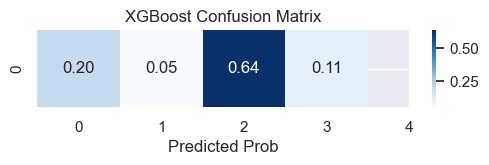

In [62]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [63]:
target = "GAC"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [64]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [65]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

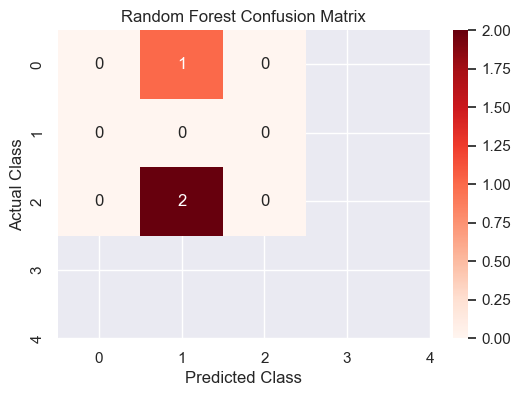

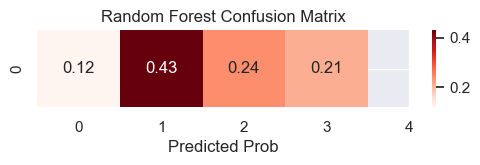

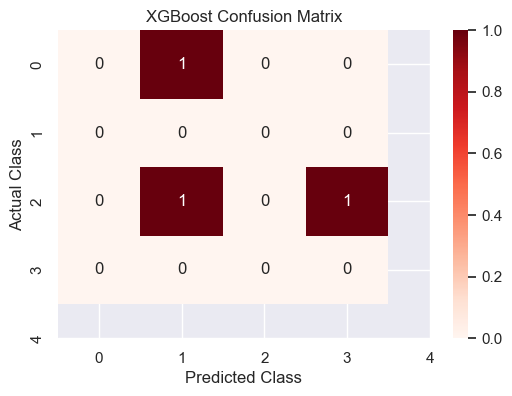

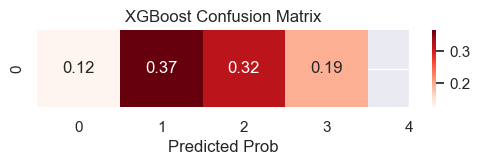

In [66]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

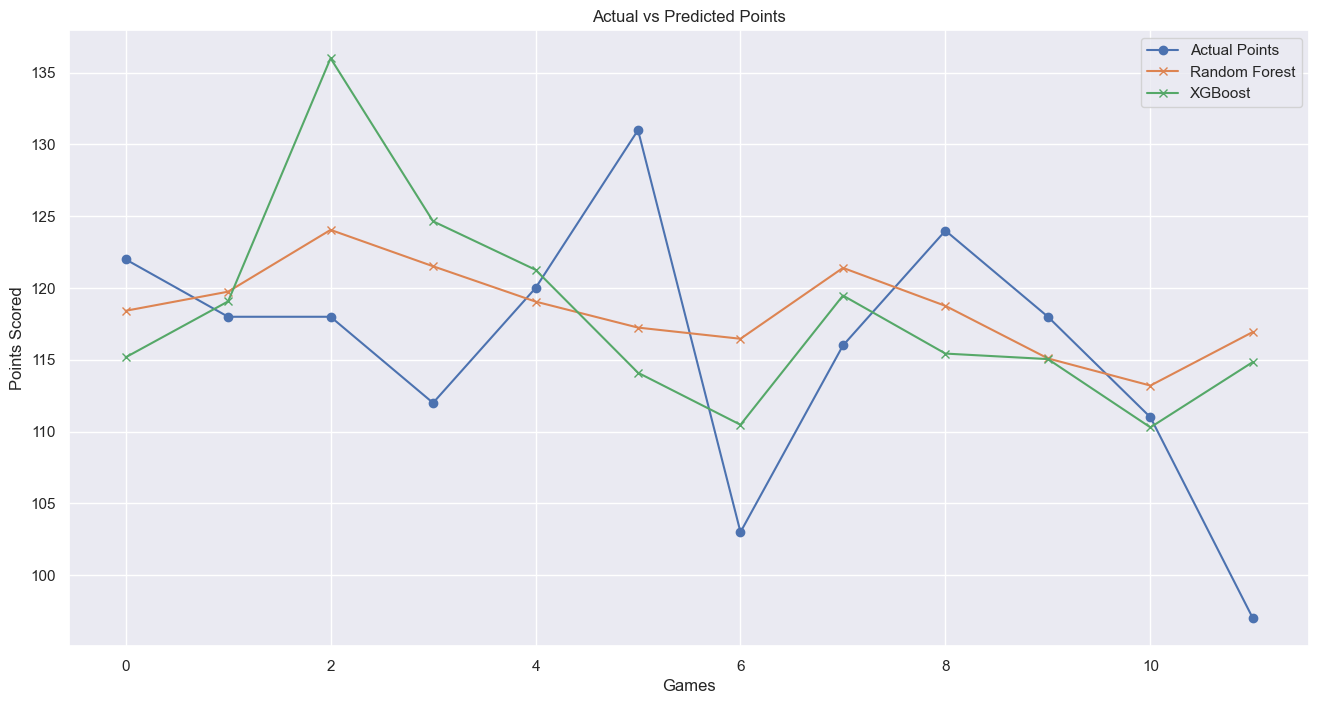

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
